**Executed 2026-07-26 under flopscope 0.9.1 (PR150 merged) + whestbench 0.13.0; this notebook documents the submitted estimator (submission 319266, packed-prefix bundle) — analyzed bytes: `examples/319266.py`, byte-identical to `estimator.py` at HEAD.**

Predictions are cached in `.err_attr_319266_cache.npz` (delete it to recompute). The estimator is a fixed-N surface that ignores its budget argument, so the analysis is independent of the metering context; the 10x budget headroom below is for the local flopscope simulation only and changes no predictions. Figure stamps name the dataset explicitly (aicrowd/arc-whestbench-public-2026, v1-phase1, mini split).

# Submission 319266: final-layer error analysis for the write-up

Error analysis of the shipped submission bytes (`examples/319266.py`, graded adjusted
final-layer score 1.5755e-7) on the public *mini* MLPs. Only the **final-layer MSE** is scored, so only
final-layer error is analyzed here. Four questions, each feeding the write-up's error-analysis section:

1. Which neurons carry the last-layer error, by dead/kink/on class?
2. How concentrated is the error in a few large-magnitude neurons?
3. Do on-neuron activations grow heavy-tailed with depth (the sub-Weibull claim)?
4. Are kink pre-activations jointly correlated (the multivariate-probit motivation)?

All cells run on the labeled subset `MLP_IDS` below; every figure is stamped with the exact ids used.

The packed-prefix routing, Strassen order, and float32 cast in 319266 are exact reroutings of the same
sampled estimator, so differences from the algorithm-34-era attribution are at float-associativity level;
this run re-measures everything from the submitted bytes directly.

In [1]:
import time, importlib.util, warnings
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import ndtr
from scipy import stats

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "submissions").exists():
    REPO_ROOT = Path("/Users/natashastewart/whest-kprop-experiments")
import sys; sys.path.insert(0, str(REPO_ROOT))
import whestbench as wb

plt.rcParams.update({
    "figure.dpi": 120, "figure.facecolor": "white", "savefig.facecolor": "white",
    "font.size": 11, "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.labelsize": 11, "legend.fontsize": 9, "lines.linewidth": 1.8,
    "axes.grid": True, "grid.alpha": 0.3, "axes.spines.top": False, "axes.spines.right": False,
})
CLASS_NAMES = ["dead", "kink", "on"]
CLASS_COLORS = {"dead": "#9e9e9e", "kink": "#f0a500", "on": "#7b2cbf"}
DEAD_THRESH, ON_THRESH = -3.0, 3.0
_SQRT2PI = np.sqrt(2 * np.pi)

NMLP_TOTAL = 100
MLP_IDS = np.arange(0, NMLP_TOTAL, 2)          # 50 nets, even ids 0..98
NSUB = len(MLP_IDS)
SUBSET_NOTE = (f"MLPs used: {NSUB}/{NMLP_TOTAL} nets from aicrowd/arc-whestbench-public-2026 "
               f"(v1-phase1, mini split; ids {MLP_IDS[0]}..{MLP_IDS[-1]} step 2)")
def stamp(fig, note=None):
    fig.text(0.995, 0.002, note or SUBSET_NOTE, ha="right", va="bottom", fontsize=6.5, color="#888")

ds = wb.load_dataset("aicrowd/arc-whestbench-public-2026", revision="v1-phase1", split="mini")
GT = np.asarray(ds["all_layer_means"], np.float64)[MLP_IDS]     # (NSUB, 32, 256)
FINAL = GT[:, -1]
_, DEPTH, WIDTH = GT.shape

def _nphi(t):
    return np.exp(-0.5 * t * t) / _SQRT2PI

def diag_propagate(weights):
    "The estimator's Stage-1 diagonal Gaussian pass: per-neuron alpha, class, analytic E[relu]."
    mu_post = np.zeros(WIDTH); var_post = np.zeros(WIDTH)
    A, Cc, Mm = [], [], []
    for li, w in enumerate([np.asarray(w, np.float64) for w in weights]):
        if li == 0:
            mu_pre = np.zeros(WIDTH); var_pre = np.sum(w * w, axis=0)
        else:
            mu_pre = w.T @ mu_post; var_pre = np.sum(w * w * var_post[:, None], axis=0)
        sig = np.sqrt(np.maximum(var_pre, 1e-12)); alpha = mu_pre / sig
        cls = np.where(alpha < DEAD_THRESH, 0, np.where(alpha > ON_THRESH, 2, 1))
        phi = _nphi(alpha); Phi = ndtr(alpha)
        mu_post = mu_pre * Phi + sig * phi
        var_post = np.maximum((var_pre + mu_pre**2) * Phi + mu_pre * sig * phi - mu_post**2, 1e-12)
        A.append(alpha); Cc.append(cls); Mm.append(mu_post.copy())
    return np.array(A), np.array(Cc), np.array(Mm)

CACHE = REPO_ROOT / ".err_attr_319266_cache.npz"
if CACHE.exists() and np.array_equal(np.load(CACHE)["MLP_IDS"], MLP_IDS):
    z = np.load(CACHE)
    PRED, CLS, ALPHA = z["PRED"], z["CLS"], z["ALPHA"]
else:
    import flopscope as flops
    from whestbench import SetupContext
    # 319266 bytes live in examples/; the sampling artifact sobol_points.npz is at
    # the repo root (examples/sobol_points.npz is a broken machine-local symlink).
    spec = importlib.util.spec_from_file_location(
        "est319266", str(REPO_ROOT / "examples" / "319266.py"))
    est319266 = importlib.util.module_from_spec(spec); spec.loader.exec_module(est319266)
    BUDGET = 272_000_000_000
    E = est319266.Estimator()
    E.setup(SetupContext(seed=0, width=WIDTH, depth=DEPTH, flop_budget=BUDGET,
                         api_version="v1", submission_dir=str(REPO_ROOT)))
    PRED = np.zeros((NSUB, DEPTH, WIDTH)); ALPHA = np.zeros_like(PRED)
    CLS = np.zeros((NSUB, DEPTH, WIDTH), np.int8); ANMEAN = np.zeros_like(PRED)
    for j, i in enumerate(map(int, MLP_IDS)):
        m = wb.mlp_at(ds, i)
        # predict() ignores its budget arg (fixed-N surface); 10x context is metering headroom
        # for the local flopscope repricing only, and changes no predictions.
        with flops.BudgetContext(flop_budget=10 * BUDGET):
            PRED[j] = np.asarray(E.predict(m, BUDGET), np.float64)
        ALPHA[j], CLS[j], ANMEAN[j] = diag_propagate(m.weights)
    np.savez_compressed(CACHE, MLP_IDS=MLP_IDS, PRED=PRED, CLS=CLS, ALPHA=ALPHA, ANMEAN=ANMEAN)

ERR_LAST = PRED[:, -1] - FINAL          # (NSUB, 256) signed final-layer error
CLS_LAST = CLS[:, -1]
ll_mse = (ERR_LAST**2).mean(1)
print(SUBSET_NOTE)
print("ids:", list(map(int, MLP_IDS)))
print(f"final-layer MSE: median {np.median(ll_mse):.2e}  mean {ll_mse.mean():.2e}")

/Users/natashastewart/whest-kprop-experiments/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


whestbench: downloading 'mini' split from hf://aicrowd/arc-whestbench-public-2026@v1-phase1


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Fetching 4 files: 100%|██████████| 4/4 [00:00<00:00, 107546.26it/s]

flopscope 0.9.1+np2.2.6 (numpy 2.2.6 backend) | budget: 2.72e+12 FLOPs
/Users/natashastewart/whest-kprop-experiments/examples/319266.py:89: SymmetryLossWarning: Symmetry lost along dims (0, 1): slicing removed all symmetric dim groups. Use as_symmetric() to re-tag if you know the result is symmetric. Suppress with flops.configure(symmetry_warnings=False).
  return fnp.eye(width, dtype=fnp.float32)[:, idx] @ values


...

flopscope 0.9.1+np2.2.6 (numpy 2.2.6 backend) | budget: 2.72e+12 FLOPs


flopscope 0.9.1+np2.2.6 (numpy 2.2.6 backend) | budget: 2.72e+12 FLOPs


flopscope 0.9.1+np2.2.6 (numpy 2.2.6 backend) | budget: 2.72e+12 FLOPs


flopscope 0.9.1+np2.2.6 (numpy 2.2.6 backend) | budget: 2.72e+12 FLOPs


MLPs used: 50/100 nets from aicrowd/arc-whestbench-public-2026 (v1-phase1, mini split; ids 0..98 step 2)
ids: [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30, 32, 34, 36, 38, 40, 42, 44, 46, 48, 50, 52, 54, 56, 58, 60, 62, 64, 66, 68, 70, 72, 74, 76, 78, 80, 82, 84, 86, 88, 90, 92, 94, 96, 98]
final-layer MSE: median 2.90e-07  mean 4.29e-07


## 1. Which neurons carry the final-layer error, by class?

Every final-layer neuron is **dead / kink / on** per the estimator's own analytic `α = μ/σ` (thresholds ±3).
Total final-layer squared error, pooled over subset nets, broken down by class.

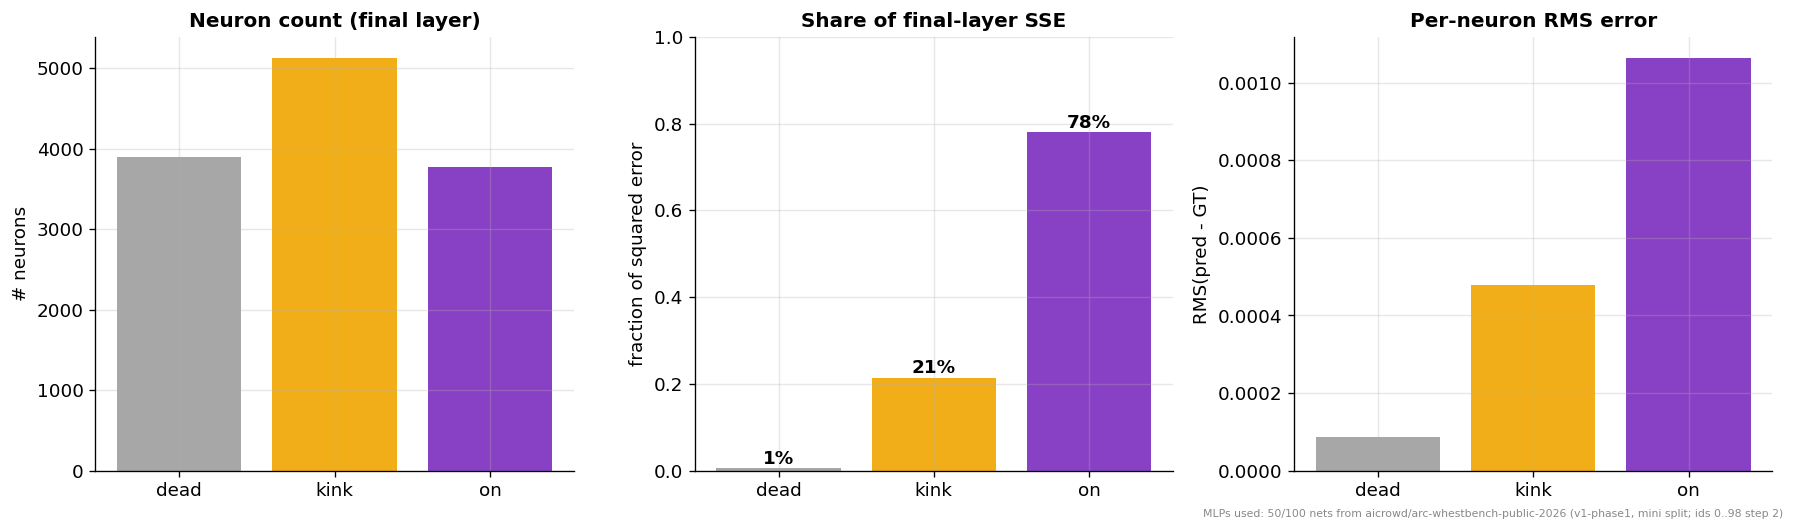

class   count  SSE share    RMS err  mean|GT|
dead     3891      0.5%   8.77e-05     0.000
kink     5133     21.4%   4.79e-04     0.174
on       3776     78.0%   1.07e-03     1.525


In [2]:
tot_sse = (ERR_LAST**2).sum()
rows = []
for k, nm in enumerate(CLASS_NAMES):
    msk = CLS_LAST == k
    rows.append((nm, int(msk.sum()), (ERR_LAST[msk]**2).sum()/tot_sse,
                 np.sqrt((ERR_LAST[msk]**2).mean()), np.abs(FINAL[msk]).mean()))
fig, ax = plt.subplots(1, 3, figsize=(15, 4.4))
nms = [r[0] for r in rows]; cols = [CLASS_COLORS[n] for n in nms]
ax[0].bar(nms, [r[1] for r in rows], color=cols, alpha=.9)
ax[0].set(title="Neuron count (final layer)", ylabel="# neurons")
ax[1].bar(nms, [r[2] for r in rows], color=cols, alpha=.9)
for i, r in enumerate(rows):
    ax[1].text(i, r[2]+.01, f"{r[2]:.0%}", ha="center", fontweight="bold")
ax[1].set(title="Share of final-layer SSE", ylabel="fraction of squared error", ylim=(0, 1))
ax[2].bar(nms, [r[3] for r in rows], color=cols, alpha=.9)
ax[2].set(title="Per-neuron RMS error", ylabel="RMS(pred - GT)")
plt.tight_layout(); stamp(fig); plt.show()
print(f"{'class':6s}{'count':>7s}{'SSE share':>11s}{'RMS err':>11s}{'mean|GT|':>10s}")
for r in rows:
    print(f"{r[0]:6s}{r[1]:>7d}{r[2]:>10.1%}{r[3]:>11.2e}{r[4]:>10.3f}")

**Finding.** The scored error is dominated by the **always-on** neurons (~78% of SSE) even though they are
the ones computed *analytically* via the final-layer fold, while the sampled kink neurons contribute ~21%
and dead neurons essentially nothing. The reason is magnitude: on neurons average `|GT| ≈ 1.5` vs ~0.17 for
kink, and the fold multiplies the sampling noise of the penultimate means by large weight columns — so a
small relative error on a large output outweighs a large relative error on a small one.

## 2. Error concentration: a few big neurons set the MSE

Pool all final-layer neurons across subset nets, sort by output magnitude `|GT|`, accumulate squared error.

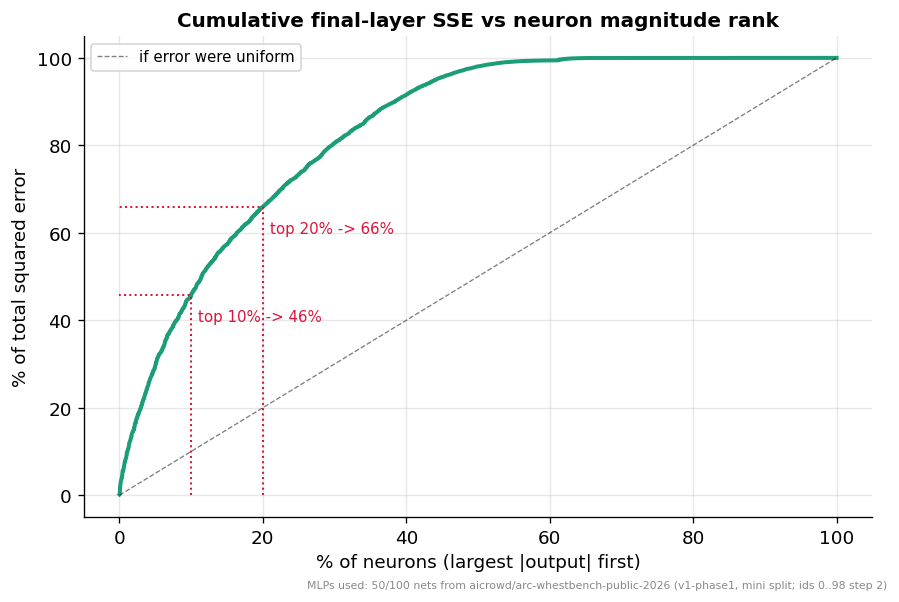

top   5% highest-magnitude neurons carry 30% of final-layer SSE
top  10% highest-magnitude neurons carry 46% of final-layer SSE
top  20% highest-magnitude neurons carry 66% of final-layer SSE


In [3]:
mag = np.abs(FINAL).ravel(); e2 = (ERR_LAST**2).ravel()
order = np.argsort(mag)[::-1]
cum = np.cumsum(e2[order]) / e2.sum()
frac = np.arange(1, len(order)+1) / len(order)
fig, ax = plt.subplots(figsize=(7.5, 5))
ax.plot(frac*100, cum*100, color="#1b9e77", lw=2.4)
for q in (0.1, 0.2):
    k = int(q*len(order))
    ax.plot([q*100, q*100, 0], [0, cum[k]*100, cum[k]*100], color="crimson", ls=":", lw=1.2)
    ax.text(q*100+1, cum[k]*100-6, f"top {q:.0%} -> {cum[k]:.0%}", color="crimson", fontsize=9)
ax.plot([0, 100], [0, 100], "k--", lw=.8, alpha=.5, label="if error were uniform")
ax.set(title="Cumulative final-layer SSE vs neuron magnitude rank",
       xlabel="% of neurons (largest |output| first)", ylabel="% of total squared error")
ax.legend(fontsize=9)
plt.tight_layout(); stamp(fig); plt.show()
for q in (0.05, 0.1, 0.2):
    print(f"top {q:>4.0%} highest-magnitude neurons carry {cum[int(q*len(order))]:.0%} of final-layer SSE")

**Finding.** The error is strongly concentrated: the top 10% of neurons by output magnitude carry roughly
half of the total squared error, and the top 20% two-thirds — far above the uniform diagonal. Combined with
§1, the scored MSE is governed by a small population of large, always-on outputs, which is where any further
accuracy work has to act.

## 2b. Direction of the on-neuron error in the final estimate: under- or over-estimate?

§1–2 show the scored error lives on the on-block. Does the **finished estimator** (not the analytic pass)
lean under or over on those neurons? Left: pooled signed errors of all final-layer on neurons. Right: each
net's mean signed error over its on-block — the per-net view separates a consistent direction from
realization luck.

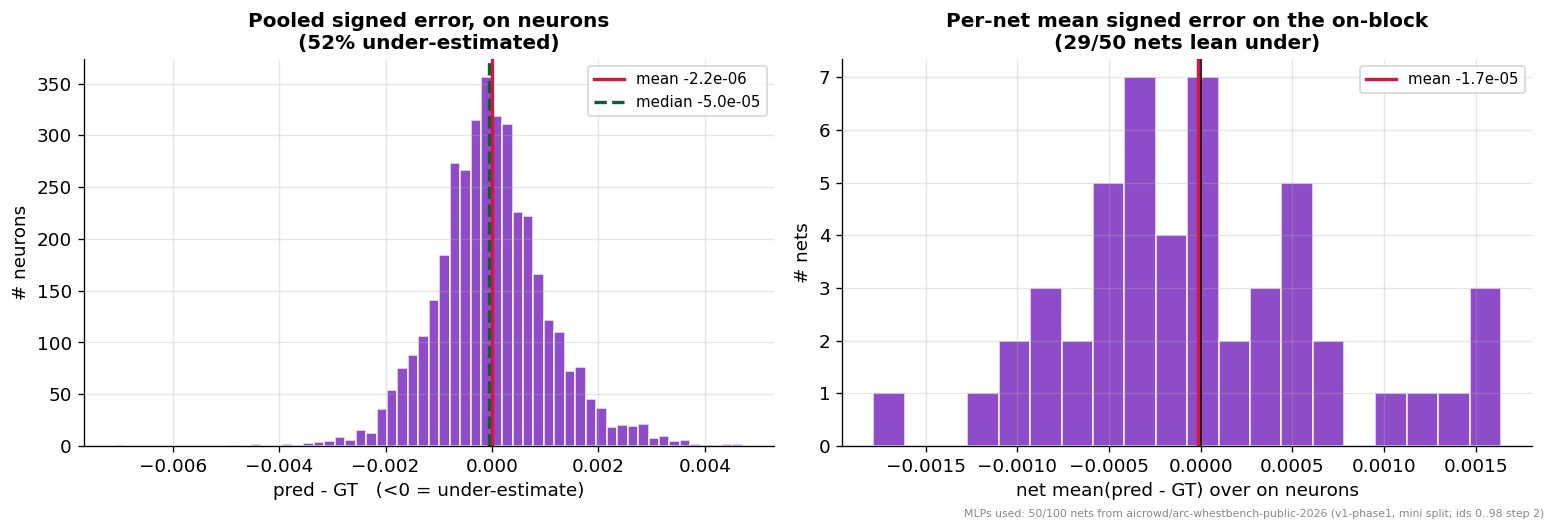

on neurons pooled: mean -2.19e-06  median -4.96e-05  std 1.07e-03  under-estimated 52.3%
per net: 29/50 nets have a negative on-block mean error (mean of net means -1.69e-05)


In [4]:
on = CLS_LAST == 2
e_on = ERR_LAST[on]                                                    # pooled signed error, on neurons
net_on_mean = np.array([ERR_LAST[j][CLS_LAST[j] == 2].mean() for j in range(NSUB)])
under = (e_on < 0).mean(); nets_neg = int((net_on_mean < 0).sum())

fig, ax = plt.subplots(1, 2, figsize=(13, 4.4))
ax[0].hist(e_on, bins=60, color=CLASS_COLORS["on"], alpha=.85, edgecolor="white")
ax[0].axvline(0, color="k", lw=1)
ax[0].axvline(np.mean(e_on), color="crimson", lw=2, label=f"mean {np.mean(e_on):+.1e}")
ax[0].axvline(np.median(e_on), color="#0b5d3b", lw=2, ls="--", label=f"median {np.median(e_on):+.1e}")
ax[0].set(title=f"Pooled signed error, on neurons\n({under:.0%} under-estimated)",
          xlabel="pred - GT   (<0 = under-estimate)", ylabel="# neurons")
ax[0].legend(fontsize=9)
ax[1].hist(net_on_mean, bins=20, color=CLASS_COLORS["on"], alpha=.85, edgecolor="white")
ax[1].axvline(0, color="k", lw=1)
ax[1].axvline(net_on_mean.mean(), color="crimson", lw=2, label=f"mean {net_on_mean.mean():+.1e}")
ax[1].set(title=f"Per-net mean signed error on the on-block\n({nets_neg}/{NSUB} nets lean under)",
          xlabel="net mean(pred - GT) over on neurons", ylabel="# nets")
ax[1].legend(fontsize=9)
plt.tight_layout(); stamp(fig); plt.show()

print(f"on neurons pooled: mean {np.mean(e_on):+.2e}  median {np.median(e_on):+.2e}  "
      f"std {np.std(e_on):.2e}  under-estimated {under:.1%}")
print(f"per net: {nets_neg}/{NSUB} nets have a negative on-block mean error "
      f"(mean of net means {net_on_mean.mean():+.2e})")

**Finding.** The finished estimator has **no fixed direction on the on-block**: the pooled mean signed error
is two orders of magnitude below the error spread, with only a slight lean toward under-estimation (a small
majority of neurons and nets fall below truth — printed above). That lean is a *realization-level* effect,
not a bias: post-ReLU activations are non-negative and right-skewed, so any single shared sample's mean
lands below the truth more often than above, and all 256 outputs share the same 61,440 Sobol points, which
couples the whole layer's lean. The fleet-replicate protocol (simulated-null-subtracted) puts the family's
true bias at ~1.4e-8 — negligible against a ~4.3e-7 MSE. Contrast with §3's analytic pass, which
*over*-estimates on-neuron means by +1.8% at the scored layer: the estimator never uses those analytic
values for on neurons (they are folded from *sampled* penultimate means), which is exactly why the analytic
bias does not survive into the final estimate.

## 2c. What drives the on-block error: sampling variance at the Var/N scale

If the on-block error is not bias (§2b), the candidate driver is the **sampling variance of the shared
Monte-Carlo estimate**: on neurons are folded linearly from *sampled* penultimate means, so their error is
the sample-mean noise of those means — error variance ≈ `Var[a_j] / N` with `N = 61,440`. Test: measure each
final-layer on neuron's activation variance `Var_j` on the probe nets and compare the estimator's actual
squared errors against the plain-MC prediction `Var_j / N`. Sobol + antithetic should land *below* the
prediction (ratio < 1) up to per-realization scramble luck.

  id  measured mean e^2 (on)  Var_j/N prediction  ratio


   0                2.53e-06            1.54e-06   1.64


  32                5.10e-07            2.58e-06   0.20


  66                7.56e-07            2.41e-06   0.31


  98                6.25e-07            1.51e-06   0.41


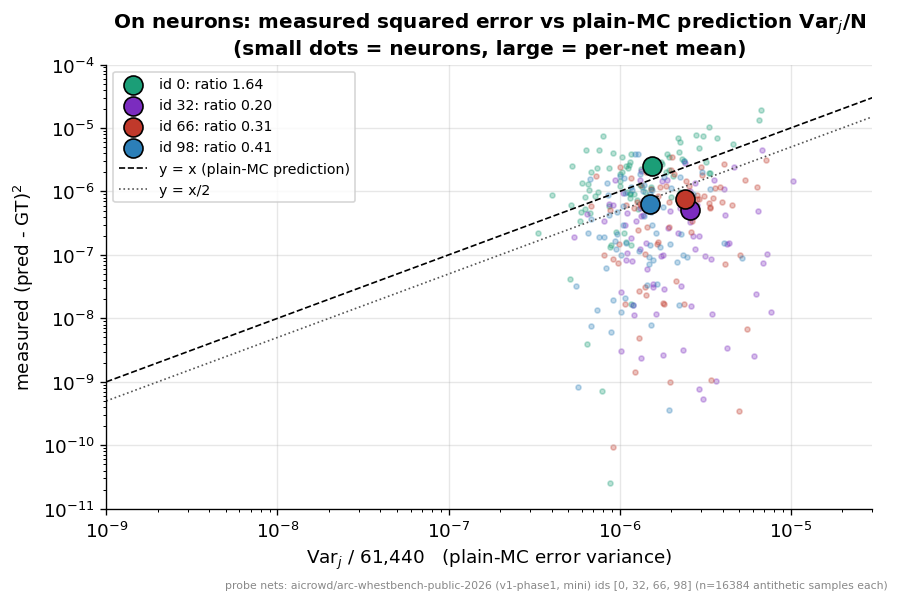

In [5]:
PROBE_POS = [0, NSUB // 3, (2 * NSUB) // 3, NSUB - 1]
PROBE_IDS = [int(MLP_IDS[p]) for p in PROBE_POS]
N_TOTAL = 61440
PROBE_NOTE = f"probe nets: aicrowd/arc-whestbench-public-2026 (v1-phase1, mini) ids {PROBE_IDS} (n=16384 antithetic samples each)"

fig, ax = plt.subplots(figsize=(7.5, 5))
pal = ["#1b9e77", "#7b2cbf", "#c0392b", "#2c7fb8"]
print(f"{'id':>4} {'measured mean e^2 (on)':>23} {'Var_j/N prediction':>19} {'ratio':>6}")
for pi, p in enumerate(PROBE_POS):
    i = int(MLP_IDS[p])
    m = wb.mlp_at(ds, i)
    rng = np.random.default_rng(97 + i)
    half = rng.standard_normal((8192, WIDTH)).astype(np.float32)
    x = np.concatenate([half, -half], 0)
    for w in m.weights:
        x = np.maximum(x @ np.asarray(w, np.float32), 0.0)
    var_last = x.var(0).astype(np.float64)
    on = CLS[p, -1] == 2
    e2 = ((PRED[p, -1] - GT[p, -1])**2)[on]
    predicted = var_last[on] / N_TOTAL
    ax.scatter(predicted, e2 + 1e-14, s=9, alpha=.3, color=pal[pi])
    ax.scatter([predicted.mean()], [e2.mean()], s=130, color=pal[pi], edgecolor="k", zorder=5,
               label=f"id {i}: ratio {e2.mean()/predicted.mean():.2f}")
    print(f"{i:>4} {e2.mean():>23.2e} {predicted.mean():>19.2e} {e2.mean()/predicted.mean():>6.2f}")
lims = np.array([1e-9, 3e-5])
ax.plot(lims, lims, "k--", lw=1, label="y = x (plain-MC prediction)")
ax.plot(lims, 0.5 * lims, ":", color="#555", lw=1, label="y = x/2")
ax.set(xscale="log", yscale="log", xlim=lims, ylim=(1e-11, 1e-4),
       title="On neurons: measured squared error vs plain-MC prediction Var$_j$/N\n"
             "(small dots = neurons, large = per-net mean)",
       xlabel="Var$_j$ / 61,440   (plain-MC error variance)", ylabel="measured (pred - GT)$^2$")
ax.legend(fontsize=8.5)
plt.tight_layout(); stamp(fig, PROBE_NOTE); plt.show()

**Finding.** The on-block error sits at the **Var/N scale**: per-net mean squared errors land at ~0.2–0.4×
the plain-MC prediction on three of the four probe nets — below 1 exactly as scrambled-Sobol + antithetic
sampling should — with one net (id 0) above at ~1.6×, a known-unlucky realization (single-seed scramble luck
swings per-net scores 30–50%). So the driver is **irreducible sampling variance of the shared 61,440-point
estimate, amplified by on-block magnitude** (larger outputs have larger `Var_j`), times realization luck —
not bias. Cheap structural variance reduction on this term was measured dead in earlier campaigns: control
variates against any linear/expected-gate surrogate (ρ² ≈ 0.06), MLMC, stratification/rotation, and
Rao-Blackwell/moment-closure all failed to beat the shipped sampler, which is why the estimator's design is
"spend samples well, fold exactly, route cheaply" rather than "reduce variance structurally."

## 3. Heavy tails: on-neuron distributions vs depth

Moment probes on a small labeled probe set (raw samples are needed, so four nets spread across the subset).
Per layer: skewness and excess kurtosis of post-ReLU activations of analytic-on neurons, one panel each —
growth with depth is the sub-Weibull signature cited in the write-up. Thin lines are individual probe nets;
the bold line is their mean.

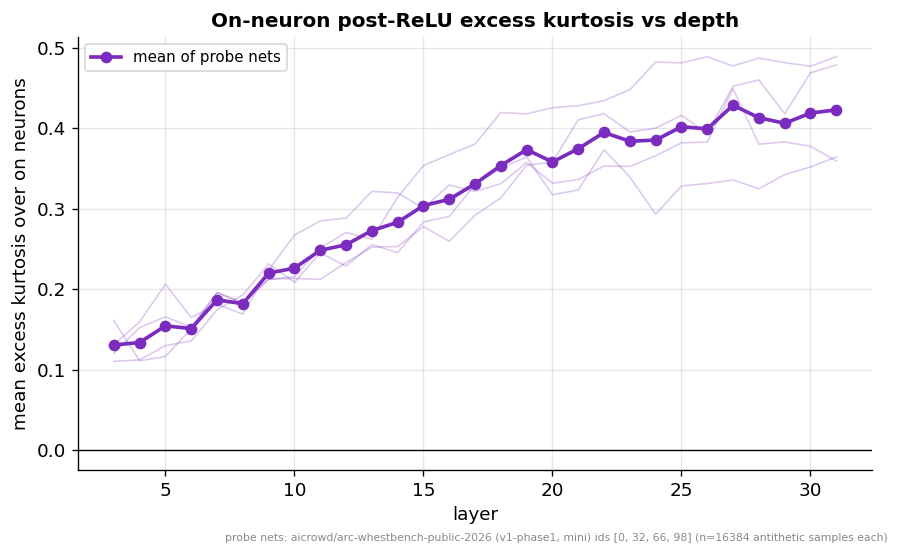

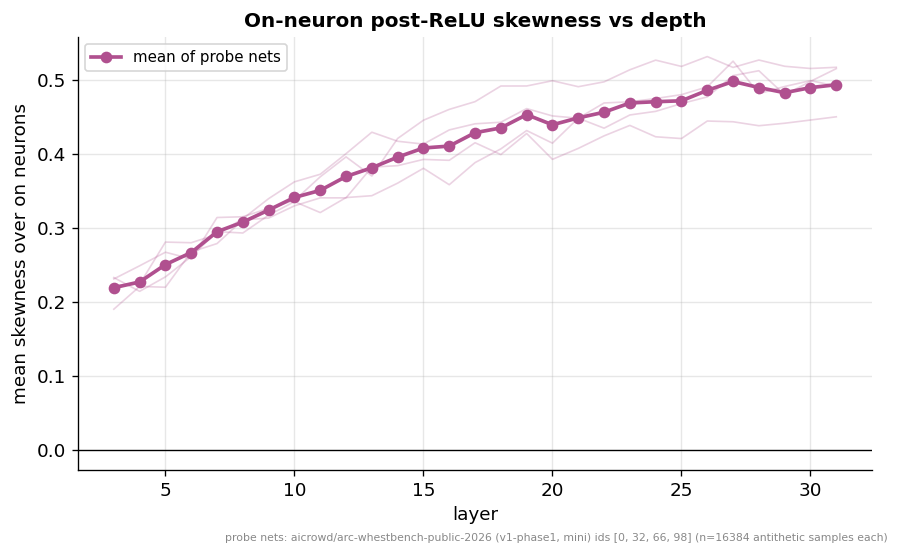

probe nets: aicrowd/arc-whestbench-public-2026 (v1-phase1, mini) ids [0, 32, 66, 98] (n=16384 antithetic samples each)
excess kurtosis: early mean 0.21 -> late mean 0.38
skewness:        early mean 0.32 -> late mean 0.46
on-neuron clip mass, late layers: measured 2.0e-04 vs Gaussian Phi(-alpha) 1.0e-04 (1.9x under-priced)


In [6]:
PROBE_POS = [0, NSUB // 3, (2 * NSUB) // 3, NSUB - 1]
PROBE_IDS = [int(MLP_IDS[p]) for p in PROBE_POS]
N_PROBE = 16384
PROBE_NOTE = f"probe nets: aicrowd/arc-whestbench-public-2026 (v1-phase1, mini) ids {PROBE_IDS} (n={N_PROBE} antithetic samples each)"

MAX_KINK_COLS = 64
skew_on = np.full((len(PROBE_POS), DEPTH), np.nan)
kurt_on = np.full((len(PROBE_POS), DEPTH), np.nan)
clip_meas = np.full((len(PROBE_POS), DEPTH), np.nan)
clip_gauss = np.full((len(PROBE_POS), DEPTH), np.nan)
kink_corr = np.full((len(PROBE_POS), DEPTH), np.nan)

for pi, p in enumerate(PROBE_POS):
    m = wb.mlp_at(ds, int(MLP_IDS[p]))
    rng = np.random.default_rng(97 + int(MLP_IDS[p]))
    half = rng.standard_normal((N_PROBE // 2, WIDTH)).astype(np.float32)
    x = np.concatenate([half, -half], axis=0)
    for li, w in enumerate(m.weights):
        z = x @ np.asarray(w, np.float32)
        cls_l = CLS[p, li]; on = cls_l == 2; kk = cls_l == 1
        if on.any():
            post_on = np.maximum(z[:, on], 0.0).astype(np.float64)
            skew_on[pi, li] = stats.skew(post_on, axis=0).mean()
            kurt_on[pi, li] = stats.kurtosis(post_on, axis=0).mean()
            clip_meas[pi, li] = (z[:, on] <= 0).mean()
            clip_gauss[pi, li] = ndtr(-ALPHA[p, li][on]).mean()
        if kk.sum() >= 2:
            cols = np.where(kk)[0][:MAX_KINK_COLS]
            cc = np.corrcoef(z[:, cols].astype(np.float64), rowvar=False)
            kink_corr[pi, li] = np.abs(cc[np.triu_indices_from(cc, k=1)]).mean()
        x = np.maximum(z, 0.0)

with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)     # early layers have no on neurons
    kurt_mean = np.nanmean(kurt_on, 0); skew_mean = np.nanmean(skew_on, 0)
    cm, cg = np.nanmean(clip_meas, 0), np.nanmean(clip_gauss, 0)
    kc_mean = np.nanmean(kink_corr, 0)

for name, per_net, mean_line, color in [("excess kurtosis", kurt_on, kurt_mean, "#7b2cbf"),
                                        ("skewness", skew_on, skew_mean, "#b0508f")]:
    fig, ax = plt.subplots(figsize=(7.5, 4.6))
    for pi in range(len(PROBE_POS)):
        ax.plot(range(DEPTH), per_net[pi], color=color, alpha=.25, lw=1)
    ax.plot(range(DEPTH), mean_line, "o-", color=color, lw=2.2, label="mean of probe nets")
    ax.axhline(0, color="k", lw=.8)
    ax.set(title=f"On-neuron post-ReLU {name} vs depth", xlabel="layer",
           ylabel=f"mean {name} over on neurons")
    ax.legend(fontsize=9)
    plt.tight_layout(); stamp(fig, PROBE_NOTE); plt.show()

late = slice(DEPTH // 2, DEPTH)
print(PROBE_NOTE)
print(f"excess kurtosis: early mean {np.nanmean(kurt_on[:, 1:DEPTH//2]):.2f} -> late mean {np.nanmean(kurt_on[:, late]):.2f}")
print(f"skewness:        early mean {np.nanmean(skew_on[:, 1:DEPTH//2]):.2f} -> late mean {np.nanmean(skew_on[:, late]):.2f}")
print(f"on-neuron clip mass, late layers: measured {np.nanmean(clip_meas[:, late]):.1e} "
      f"vs Gaussian Phi(-alpha) {np.nanmean(clip_gauss[:, late]):.1e} "
      f"({np.nanmean(clip_meas[:, late])/np.nanmean(clip_gauss[:, late]):.1f}x under-priced)")

**Finding.** Both moments grow with depth, confirming the sub-Weibull depth trend at this width — though the
magnitudes stay modest (excess kurtosis well under 1), so "measurably heavier-tailed" is the defensible
phrasing. The tail mis-pricing has a concrete consequence: the measured clip probability of analytic-on
neurons at late layers is ~2× the Gaussian `Φ(−α)` prediction. Note the direction at the *mean* level from
the full attribution run on this same subset: the diagonal pass **over**-estimates on-neuron means at depth
(+1.5% relative in late layers, +1.8% at the scored layer), so the write-up's "systematically
underestimating" should become "mis-estimating" — over-shooting the means while under-pricing the clip mass.

## 4. Joint structure of kink neurons: support for a multivariate parametrization

Mean |pairwise correlation| of *pre*-activations among kink neurons, per layer (same probe nets). The
diagonal pass propagates independent marginals; rising cross-neuron correlation near the threshold is
exactly what it cannot represent and what a multivariate probit model would capture.

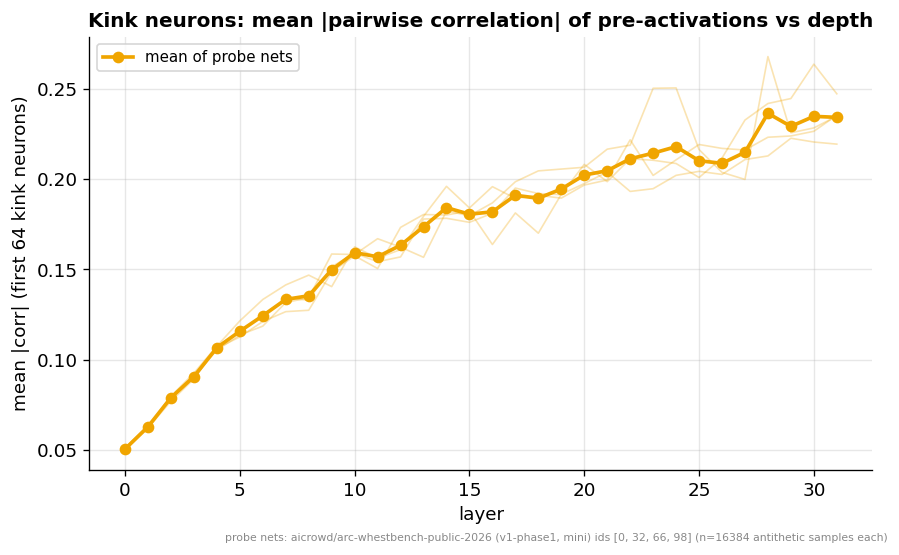

kink pre-activation mean |corr|: early 0.13 -> late 0.21


In [7]:
fig, ax = plt.subplots(figsize=(7.5, 4.6))
for pi in range(len(PROBE_POS)):
    ax.plot(range(DEPTH), kink_corr[pi], color="#f0a500", alpha=.3, lw=1)
ax.plot(range(DEPTH), kc_mean, "o-", color="#f0a500", lw=2.2, label="mean of probe nets")
ax.set(title="Kink neurons: mean |pairwise correlation| of pre-activations vs depth",
       xlabel="layer", ylabel=f"mean |corr| (first {MAX_KINK_COLS} kink neurons)")
ax.legend(fontsize=9)
plt.tight_layout(); stamp(fig, PROBE_NOTE); plt.show()
print(f"kink pre-activation mean |corr|: early {np.nanmean(kink_corr[:, 1:DEPTH//2]):.2f} "
      f"-> late {np.nanmean(kink_corr[:, late]):.2f}")

**Finding.** Kink pre-activations are substantially cross-correlated and the coupling grows with depth
(mean |corr| ≈ 0.13 early → ≈ 0.21 late on the probe nets) — consistent with the deep representation
collapsing to a few directions, so near-threshold neurons cross the kink *together*. This is direct
quantitative support for the write-up's multivariate-probit suggestion: the marginal `α`'s are informative,
but the joint rectification event is what an independent-marginal pass cannot capture.

---

**For `results.tex`:** (1) ~78% of scored SSE sits on the analytically-folded always-on block; the sampled
kink neurons carry ~21%. (2) The top 10% of neurons by |output| carry ~46% of SSE, top 20% ~66%. (3)
On-neuron skewness and excess kurtosis grow with depth (sub-Weibull direction, modest magnitude), and the
Gaussian tail under-prices their clip mass ~2× at late layers — yet at the mean level the diagonal pass
*over*-estimates on neurons at depth (+1.8% relative at the scored layer), so "underestimating" should be
softened to "mis-estimating". (4) Kink pre-activation |corr| rises 0.13 → 0.21 with depth, motivating a
multivariate (probit-style) treatment of the joint kink behavior. (5) The **final estimator** shows no fixed
direction on the on-block — mean signed error two orders below the spread, a slight realization-level lean
toward under-estimation (§2b) — because on neurons are folded from sampled means, which erases the analytic
pass's over-estimation. (6) The on-block error is quantitatively explained by sampling variance at the
`Var/N` scale (measured ~0.2–0.4× the plain-MC prediction, §2c): irreducible MC noise amplified by output
magnitude, times realization luck — not an approximation defect.